# XGBoost Taxi Type Classification

Classify NYC taxi type (yellow vs green) in two settings: (Part A) raw trip-level data, (Part B) pivoted tables reduced to PC1–PC5 of the hourly profile.

## 1. Config

Path to raw parquet (directory or file), path to pivoted parquet (Part B), max rows per class for Part A (or None), random seed, train fraction.

---

In [12]:
PATH_RAW = "s3://dsc291-ucsd/taxi/Dataset/2023/"
PATH_PIVOTED = "data/input/taxi_wide_table.parquet"
MAX_ROWS_PER_CLASS = 50_000
RANDOM_SEED = 0
TRAIN_FRACTION = 0.8

## Part A: Classification from Raw Trip Data

## 2. Load and Prepare

Discover parquet files, normalize column names (e.g. Trip_Pickup_DateTime → tpep_pickup_datetime), load one file per taxi type with Dask, sample per class, compute to pandas. Derive trip_duration_min, hour, day_of_week. Features: trip_distance, trip_duration_min, hour, day_of_week, passenger_count. Drop rows with missing or invalid values.

In [2]:
from __future__ import annotations
from pathlib import Path
from typing import List
import fsspec


def is_s3_path(path: str | Path) -> bool:
    return str(path).startswith("s3://")


def get_filesystem(path: str | Path):
    if is_s3_path(path):
        return fsspec.filesystem("s3", anon=True)
    return fsspec.filesystem("file")


def discover_parquet_files(input_path: str | Path) -> List[str]:
    """Discover all .parquet files from directory or single file."""
    input_path = str(input_path)
    if input_path.endswith(".parquet"):
        return [input_path]
    fs = get_filesystem(input_path)
    if is_s3_path(input_path):
        stripped = input_path.replace("s3://", "", 1).rstrip("/")
        files = []
        for root, _, filenames in fs.walk(stripped):
            for name in filenames:
                if name.endswith(".parquet"):
                    files.append(f"s3://{root}/{name}")
    else:
        base = Path(input_path)
        if not base.exists():
            raise FileNotFoundError(f"Input path does not exist: {input_path}")
        files = [str(p) for p in base.rglob("*.parquet") if p.is_file()]
    files.sort()
    if not files:
        raise FileNotFoundError(f"No Parquet files found under {input_path}")
    return files


def infer_taxi_type_from_path(file_path: str | Path) -> str:
    """Infer taxi type (yellow, green, fhv, hvfhv) from file path."""
    path = str(file_path).lower()
    for taxi in ["yellow", "green", "fhv", "hvfhv"]:
        if taxi in path:
            return taxi
    return "unknown"


def find_pickup_datetime_col(columns: List[str]) -> str | None:
    candidates = ["Trip_Pickup_DateTime", "lpep_pickup_datetime", "pickup_datetime", "tpep_pickup_datetime"]
    lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None


def find_dropoff_datetime_col(columns: List[str]) -> str | None:
    candidates = ["Trip_Dropoff_DateTime", "lpep_dropoff_datetime", "dropoff_datetime", "dropOff_datetime", "tpep_dropoff_datetime"]
    lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None


def find_dist_col(columns: List[str]) -> str | None:
    candidates = ["trip_distance", "Trip_Distance", "trip_miles", "Trip_Miles"]
    lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None


def find_passenger_count_col(columns: List[str]) -> str | None:
    candidates = ["passenger_count", "Passenger_Count"]
    lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None


def normalize_columns(df_columns: List[str]) -> dict:
    """Build rename dict to normalize schema to tpep_* / trip_distance / passenger_count."""
    renames = {}
    pickup = find_pickup_datetime_col(df_columns)
    if pickup:
        renames[pickup] = "tpep_pickup_datetime"
    dropoff = find_dropoff_datetime_col(df_columns)
    if dropoff:
        renames[dropoff] = "tpep_dropoff_datetime"
    dist = find_dist_col(df_columns)
    if dist and dist != "trip_distance":
        renames[dist] = "trip_distance"
    pax = find_passenger_count_col(df_columns)
    if pax and pax != "passenger_count":
        renames[pax] = "passenger_count"
    return renames

In [3]:
import dask.dataframe as dd
import pandas as pd
import numpy as np

# Discover files and group by taxi type
all_files = discover_parquet_files(PATH_RAW)
by_type = {}
for f in all_files:
    t = infer_taxi_type_from_path(f)
    if t not in by_type:
        by_type[t] = []
    by_type[t].append(f)

# Keep only yellow and green; pick one file per type
wanted = {k: v[0] for k, v in by_type.items() if k in ("yellow", "green")}
if "yellow" not in wanted or "green" not in wanted:
    raise ValueError(f"Need both yellow and green parquet files. Found: {list(by_type.keys())}")

storage_options = {"anon": True} if str(PATH_RAW).startswith("s3://") else {}
parts = []
for taxi_type, path in wanted.items():
    ddf = dd.read_parquet(path, engine="pyarrow", storage_options=storage_options)
    cols = list(ddf.columns)
    renames = normalize_columns(cols)
    if renames:
        ddf = ddf.rename(columns=renames)
    ddf = ddf.assign(taxi_type=taxi_type)
    parts.append(ddf)

combined_ddf = dd.concat(parts, axis=0, ignore_index=True)
raw_df = combined_ddf.compute()

# Sample per class in pandas (avoids Dask length computation)
if MAX_ROWS_PER_CLASS is not None:
    sampled = []
    for tt in wanted.keys():
        sub = raw_df.loc[raw_df["taxi_type"] == tt]
        if len(sub) > MAX_ROWS_PER_CLASS:
            sub = sub.sample(n=MAX_ROWS_PER_CLASS, random_state=RANDOM_SEED, replace=False)
        sampled.append(sub)
    raw_df = pd.concat(sampled, ignore_index=True)
print(f"Loaded {len(raw_df)} rows from {list(wanted.keys())}")

Loaded 100000 rows from ['green', 'yellow']


In [4]:
# Derive features and clean
df = raw_df.copy()
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")
df["trip_duration_min"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek

# Drop missing
df = df.dropna(subset=["trip_distance", "trip_duration_min", "passenger_count", "hour", "day_of_week"])

# Drop invalid (non-positive distance/duration)
df = df.loc[(df["trip_distance"] > 0) & (df["trip_duration_min"] > 0)]

# Select features and target
FEATURE_COLS = ["trip_distance", "trip_duration_min", "hour", "day_of_week", "passenger_count"]
X = df[FEATURE_COLS].copy()
print(f"Cleaned: {len(X)} rows. Class counts:\n{df['taxi_type'].value_counts()}")

Cleaned: 92711 rows. Class counts:
taxi_type
yellow    48205
green     44506
Name: count, dtype: int64


## 3. Train and Evaluate

Stratified train/validation split, fit XGBClassifier (multi-class: objective="multi:softmax"), report classification report and accuracy.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(df["taxi_type"])
class_names = le.classes_.tolist()
num_class = len(class_names)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_enc, train_size=TRAIN_FRACTION, stratify=y_enc, random_state=RANDOM_SEED
)

model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=num_class,
    random_state=RANDOM_SEED,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred, target_names=class_names))
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")

              precision    recall  f1-score   support

       green       0.61      0.65      0.63      8902
      yellow       0.65      0.62      0.63      9641

    accuracy                           0.63     18543
   macro avg       0.63      0.63      0.63     18543
weighted avg       0.63      0.63      0.63     18543

Accuracy: 0.6300


## 4. Interpret

One figure with three panels: (1) confusion matrix, (2) feature importance (horizontal bar chart), (3) value range (boxplot) of features for one class (e.g. yellow).

C:\Users\dgt60\AppData\Local\Temp\ipykernel_39148\2475245222.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot([subset[c].values for c in FEATURE_COLS], labels=FEATURE_COLS, patch_artist=True)


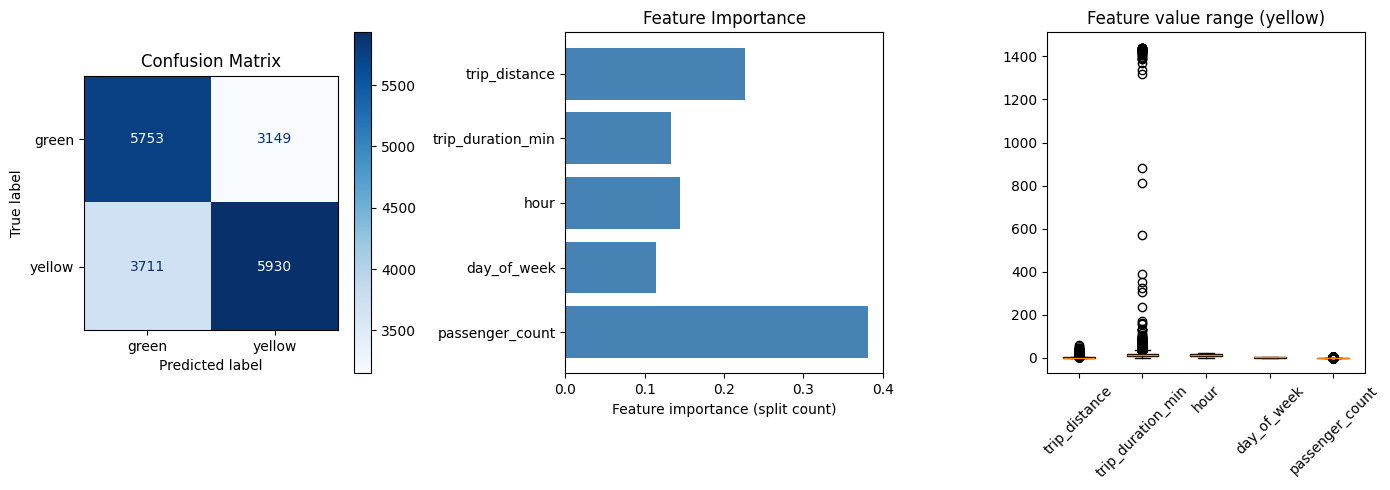

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# (1) Confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix")

# (2) Feature importance (split count)
imps = model.feature_importances_
axes[1].barh(FEATURE_COLS, imps, color="steelblue")
axes[1].set_xlabel("Feature importance (split count)")
axes[1].set_title("Feature Importance")
axes[1].invert_yaxis()

# (3) Boxplot of features for one class (e.g. yellow)
sample_class = "yellow"
subset = df.loc[df["taxi_type"] == sample_class][FEATURE_COLS]
bp = axes[2].boxplot([subset[c].values for c in FEATURE_COLS], labels=FEATURE_COLS, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightsteelblue")
axes[2].set_title(f"Feature value range ({sample_class})")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

---
## Part B: Classification from Pivoted Tables

Read pivoted parquet (rows = date, taxi_type, pickup_place; columns = hour_0...hour_23). Convert hourly counts to proportions, fit PCA, use PC1–PC5 as features.

### Part B.1 Load

Read pivoted parquet with Dask; keep rows with valid taxi_type and hour_0...hour_23; restrict to yellow and green.

In [13]:
hour_cols = [f"hour_{i}" for i in range(24)]
ddf_b = dd.read_parquet(PATH_PIVOTED, engine="pyarrow")
df_b = ddf_b.compute()
df_b = df_b.dropna(subset=["taxi_type"] + hour_cols)
df_b = df_b.loc[df_b["taxi_type"].str.lower().isin(["yellow", "green"])]
df_b = df_b.reset_index(drop=True)
print(f"Part B loaded: {len(df_b)} rows. Class counts:\n{df_b['taxi_type'].value_counts()}")

Part B loaded: 655584 rows. Class counts:
taxi_type
yellow    470117
green     185467
Name: count, dtype: int64[pyarrow]


### Part B.2 Features

Convert hourly counts to row proportions; fit PCA (5 components) on the 24-dimensional profile; use PC1–PC5 as features.

In [14]:
from sklearn.decomposition import PCA

# Row proportions (each row sums to 1)
H = df_b[hour_cols].values.astype(float)
row_sums = H.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
H_prop = H / row_sums

# Fit PCA and transform
n_components = 5
pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
X_b = pca.fit_transform(H_prop)
PC_COLS = [f"PC{i+1}" for i in range(n_components)]
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

PCA explained variance ratio: [0.3525966  0.15960926 0.12874766 0.04772951 0.0360049 ]


### Part B.3 Train and Evaluate

Encode taxi_type (LabelEncoder); stratified split; fit XGBClassifier; report classification report and accuracy.

In [15]:
le_b = LabelEncoder()
y_b = le_b.fit_transform(df_b["taxi_type"])
class_names_b = le_b.classes_.tolist()
num_class_b = len(class_names_b)

X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_b, y_b, train_size=TRAIN_FRACTION, stratify=y_b, random_state=RANDOM_SEED
)

model_b = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=num_class_b,
    random_state=RANDOM_SEED,
)
model_b.fit(X_train_b, y_train_b)

y_pred_b = model_b.predict(X_val_b)
print(classification_report(y_val_b, y_pred_b, target_names=class_names_b))
print(f"Accuracy: {accuracy_score(y_val_b, y_pred_b):.4f}")

              precision    recall  f1-score   support

       green       0.71      0.52      0.60     37093
      yellow       0.83      0.92      0.87     94024

    accuracy                           0.80    131117
   macro avg       0.77      0.72      0.74    131117
weighted avg       0.80      0.80      0.79    131117

Accuracy: 0.8042


### Part B.4 Interpret

Plot confusion matrix and feature importance (which PCs matter most).

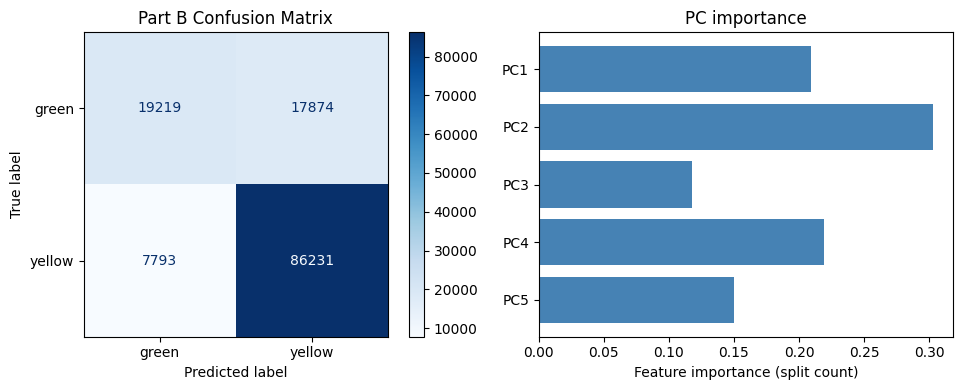

In [16]:
fig_b, axes_b = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix
cm_b = confusion_matrix(y_val_b, y_pred_b)
disp_b = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=class_names_b)
disp_b.plot(ax=axes_b[0], cmap="Blues")
axes_b[0].set_title("Part B Confusion Matrix")

# Feature importance (PCs)
imps_b = model_b.feature_importances_
axes_b[1].barh(PC_COLS, imps_b, color="steelblue")
axes_b[1].set_xlabel("Feature importance (split count)")
axes_b[1].set_title("PC importance")
axes_b[1].invert_yaxis()

plt.tight_layout()
plt.show()